I want to predict all the times for one store

In [1]:
# Add project root to path so we can import from data_manipulation and model
import sys
from pathlib import Path

def _find_project_root():
    cwd = Path.cwd()
    if (cwd / "data_manipulation").is_dir():
        return cwd
    if (cwd.parent / "data_manipulation").is_dir():
        return cwd.parent
    return cwd  # fallback

project_root = _find_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from functools import partial

# Imports from data_manipulation and model
from data_manipulation.data_split import create_dataloader, DemandDataset
from model.functions import pinball_loss, rmse, train, get_test_loss, pinball_loss_tensor

In [3]:
class simple_net(nn.Module):
    def __init__(self,input_size, hidden_size=10, output_size=1):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [4]:
all_specs = [
    "7_day_rolling_ema",	
    "7_day_rolling_mean",	
    "30_day_rolling_ema",	
    "diff_180_day",	
    "diff_90_day",	
    "30_day_rolling_mean",	
    "diff_30_day",	
    "7_day_rolling_min",	
    "7_day_lag",	
    "30_day_rolling_min",	
    "14_day_lag",	
    "diff_365_day",	
]

In [5]:
# Get data for spec
train_loader, val_loader, test_loader = create_dataloader(
    batch_size=8, 
    test_batch_size=1,
    pin_memory=False,
    specs=all_specs,
    combine_items=True,
    combine_stores=True
    )

In [6]:
h_cost = 1
l_cost = 3

net = simple_net(train_loader.dataset.x.shape[1], hidden_size=train_loader.dataset.x.shape[1], output_size=train_loader.dataset.y.shape[1])
loss = partial(pinball_loss, h_cost=h_cost, l_cost=l_cost)
loss_tensor = partial(pinball_loss_tensor, h_cost=h_cost, l_cost=l_cost)
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)

train_losses, val_losses = train(net, optimizer, loss, train_loader, val_loader, epochs=200, eval_interval=10, device="cpu")

test_loss = get_test_loss(net, test_loader, loss, "cpu")

Training: 100%|██████████| 200/200 [01:38<00:00,  2.03step/s, train_loss=12.7827]                   


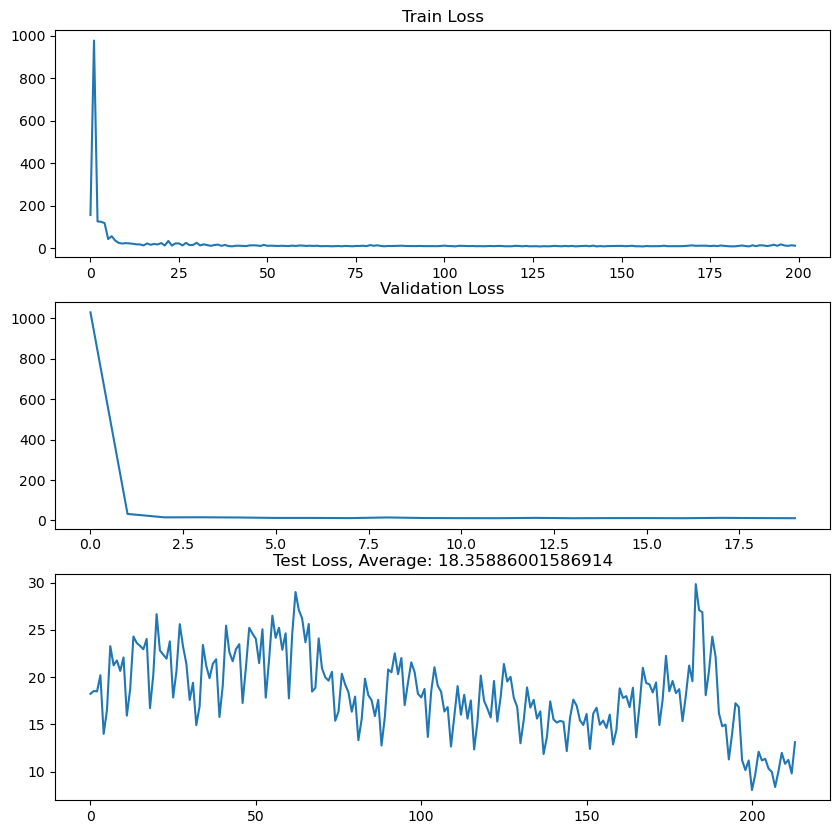

In [7]:
fig, axs = plt.subplots(3, 1, figsize=(10, 10))
axs[0].plot(train_losses)
axs[0].set_title("Train Loss")
axs[1].plot(val_losses)
axs[1].set_title("Validation Loss")
axs[2].plot(test_loss)
axs[2].set_title(f"Test Loss, Average: {torch.tensor(test_loss).mean()}")
plt.show()

In [8]:
test_data = test_loader.dataset.x
test_y = test_loader.dataset.y
test_y_hat = net(test_data)
test_loss_tensor = loss_tensor(test_y_hat, test_y)



In [10]:
print(test_loader.dataset.y_columns)

['store_1_item_1', 'store_1_item_2', 'store_1_item_3', 'store_1_item_4', 'store_1_item_5', 'store_1_item_6', 'store_1_item_7', 'store_1_item_8', 'store_1_item_9', 'store_1_item_10', 'store_1_item_11', 'store_1_item_12', 'store_1_item_13', 'store_1_item_14', 'store_1_item_15', 'store_1_item_16', 'store_1_item_17', 'store_1_item_18', 'store_1_item_19', 'store_1_item_20', 'store_1_item_21', 'store_1_item_22', 'store_1_item_23', 'store_1_item_24', 'store_1_item_25', 'store_1_item_26', 'store_1_item_27', 'store_1_item_28', 'store_1_item_29', 'store_1_item_30', 'store_1_item_31', 'store_1_item_32', 'store_1_item_33', 'store_1_item_34', 'store_1_item_35', 'store_1_item_36', 'store_1_item_37', 'store_1_item_38', 'store_1_item_39', 'store_1_item_40', 'store_1_item_41', 'store_1_item_42', 'store_1_item_43', 'store_1_item_44', 'store_1_item_45', 'store_1_item_46', 'store_1_item_47', 'store_1_item_48', 'store_1_item_49', 'store_1_item_50', 'store_2_item_1', 'store_2_item_2', 'store_2_item_3', 'sto

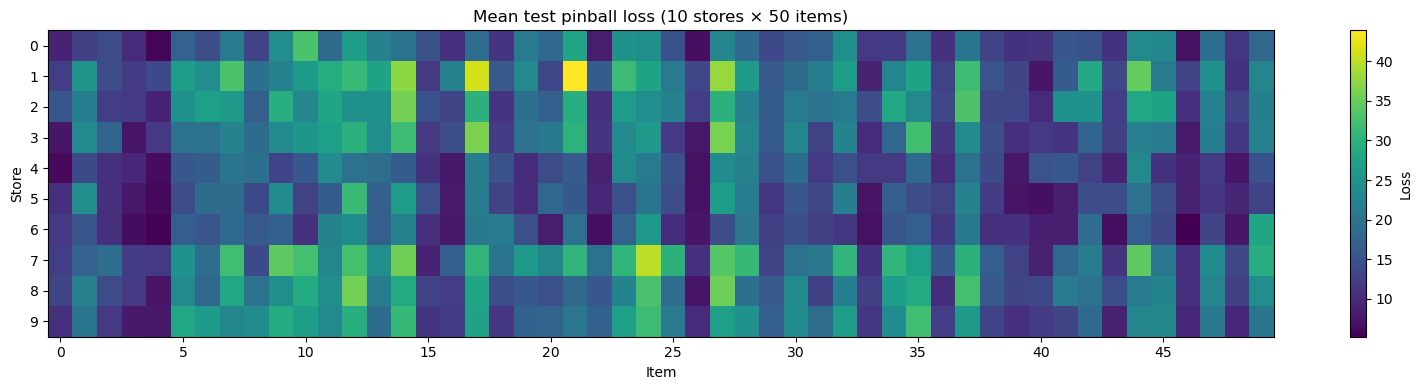

In [11]:
import numpy as np

# Per (store, item) mean pinball loss over test rows; columns are store-major: store_1_item_1…store_1_item_50, …
loss_per_col = test_loss_tensor.mean(dim=0).detach().cpu().numpy()
n_stores, n_items = 10, 50
loss_matrix = loss_per_col.reshape(n_stores, n_items)

fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(loss_matrix, aspect="auto", cmap="viridis")
ax.set_xlabel("Item")
ax.set_ylabel("Store")
ax.set_title("Mean test pinball loss (10 stores × 50 items)")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Loss")
ax.set_xticks(np.arange(0, n_items, 5))
ax.set_yticks(np.arange(n_stores))
plt.tight_layout()
plt.show()

In [12]:
# Mean test pinball loss per target column, greatest to least
ranked = sorted(
    zip(test_loader.dataset.y_columns, loss_per_col),
    key=lambda t: t[1],
    reverse=True,
)
for col, loss_val in ranked:
    print(col, loss_val)


store_2_item_22 43.901222
store_2_item_18 41.43388
store_8_item_25 40.01309
store_2_item_28 37.915604
store_2_item_15 37.38513
store_4_item_18 36.275932
store_4_item_28 36.14865
store_9_item_13 35.833935
store_3_item_15 35.759884
store_8_item_15 35.486717
store_9_item_28 35.327503
store_2_item_45 34.69875
store_8_item_10 34.379295
store_8_item_45 34.24434
store_8_item_28 33.694912
store_3_item_38 33.026768
store_1_item_11 32.974667
store_2_item_8 32.90079
store_9_item_25 32.83615
store_8_item_13 32.573006
store_9_item_38 32.560493
store_8_item_11 32.291027
store_4_item_36 32.201153
store_8_item_8 32.06769
store_10_item_36 31.995905
store_4_item_15 31.963795
store_2_item_38 31.948198
store_10_item_25 31.752712
store_2_item_24 31.669308
store_6_item_13 31.644823
store_2_item_13 31.3416
store_8_item_29 31.199615
store_10_item_15 31.178373
store_8_item_35 30.75348
store_8_item_33 30.744663
store_8_item_24 30.74159
store_8_item_18 30.635647
store_8_item_22 30.525537
store_4_item_22 30.22563